# **Energy resolution**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from matplotlib.ticker import MultipleLocator

# **Energy resolution with copper plate**

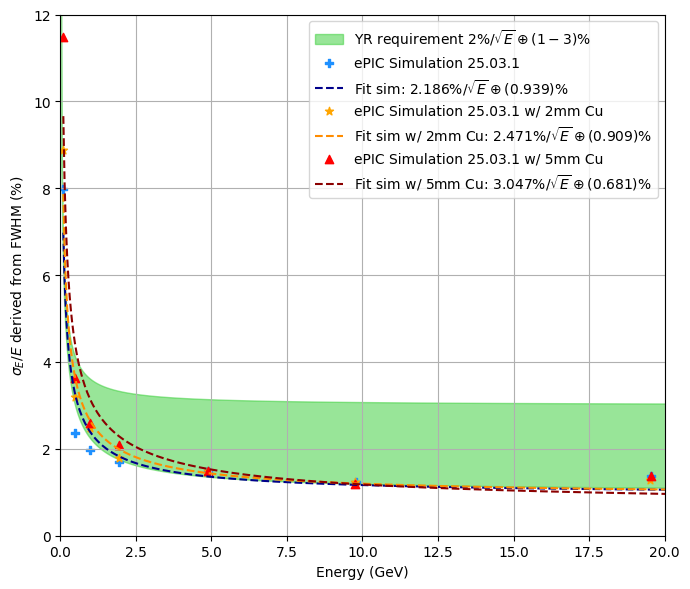

In [ ]:
# Create energy array
E = np.linspace(0.01, 21, 500)  # Avoid division by zero

# Define the upper and lower bounds of the theoretical curve
fit_curve_up = np.sqrt((0.02 / np.sqrt(E))**2 + 0.03**2) * 100  # upper bound
fit_curve_low = np.sqrt((0.02 / np.sqrt(E))**2 + 0.01**2) * 100  # lower bound

# Data points original
peak_energy = np.array([0.0865, 0.4856, 0.9768, 1.9550, 4.9031, 9.7696, 19.5563])
FWHM = np.array([0.0069, 0.0115, 0.0192, 0.0333, 0.0729, 0.1217, 0.2708])
energy_resolution = FWHM / peak_energy * 100

# Data points 2mm of Cu
peak_energy_2mmCu = np.array([0.0834, 0.4817, 0.9720, 1.9504, 4.8927, 9.7609, 19.5250])
FWHM_2mmCu = np.array([0.0074, 0.0154, 0.0240, 0.0350, 0.0729, 0.1217, 0.2500])
energy_resolution_2mmCu = FWHM_2mmCu / peak_energy_2mmCu * 100

# Data points 5mm of Cu
peak_energy_5mmCu = np.array([0.0775, 0.4751, 0.9662, 1.9446, 4.8927, 9.763, 19.5563]) #5, 2, 1, 0.5, 0.1
FWHM_5mmCu = np.array([0.0089, 0.0173, 0.0250, 0.0408, 0.0729, 0.117, 0.2708])
energy_resolution_5mmCu = FWHM_5mmCu / peak_energy_5mmCu * 100

# Define the fitting function
def resolution_model(E, a, b):
    return np.sqrt((a / np.sqrt(E))**2 + b**2)

# Perform the curve fitting
params, covariance = curve_fit(resolution_model, peak_energy, energy_resolution, p0=[0.02, 0.01])
a_fit, b_fit = params

params_2mmCu, covariance = curve_fit(resolution_model, peak_energy_2mmCu, energy_resolution_2mmCu, p0=[0.02, 0.01])
a_fit_2mmCu, b_fit_2mmCu = params_2mmCu

params_5mmCu, covariance = curve_fit(resolution_model, peak_energy_5mmCu, energy_resolution_5mmCu, p0=[0.02, 0.01])
a_fit_5mmCu, b_fit_5mmCu = params_5mmCu

# Generate fitted curve
fit_E = np.linspace(0.1, 21, 500)
fit_Sigma = resolution_model(fit_E, a_fit, b_fit)

fit_E_2mmCu = np.linspace(0.1, 21, 500)
fit_Sigma_2mmCu = resolution_model(fit_E_2mmCu, a_fit_2mmCu, b_fit_2mmCu)

fit_E_5mmCu = np.linspace(0.1, 21, 500)
fit_Sigma_5mmCu = resolution_model(fit_E_5mmCu, a_fit_5mmCu, b_fit_5mmCu)

# Plotting the acceptance zone
plt.figure(figsize=(7, 6))
plt.fill_between(E, fit_curve_up, fit_curve_low, color='limegreen', alpha=0.5, label='YR requirement $2\\%/\\sqrt{E} \\oplus (1-3)\\%$')
# Plotting the energy points
plt.scatter(peak_energy, energy_resolution, marker='P', color='dodgerblue', label='ePIC Simulation 25.03.1')
plt.plot(fit_E, fit_Sigma, color='darkblue', linestyle='--', label=f'Fit sim: ${a_fit:.3f}\\%/\\sqrt{{E}} \\oplus ({b_fit:.3f})\\%$')
# Plotting the energy with 2mm of Cu
plt.scatter(peak_energy_2mmCu, energy_resolution_2mmCu, marker='*', color='orange', label='ePIC Simulation 25.03.1 w/ 2mm Cu')
plt.plot(fit_E_2mmCu, fit_Sigma_2mmCu, color='darkorange', linestyle='--', label=f'Fit sim w/ 2mm Cu: ${a_fit_2mmCu:.3f}\\%/\\sqrt{{E}} \\oplus ({b_fit_2mmCu:.3f})\\%$')
# Plotting the energy with 2mm of Cu
plt.scatter(peak_energy_5mmCu, energy_resolution_5mmCu, marker='^', color='red', label='ePIC Simulation 25.03.1 w/ 5mm Cu')
plt.plot(fit_E_5mmCu, fit_Sigma_5mmCu, color='darkred', linestyle='--', label=f'Fit sim w/ 5mm Cu: ${a_fit_5mmCu:.3f}\\%/\\sqrt{{E}} \\oplus ({b_fit_5mmCu:.3f})\\%$')

plt.xlabel('Energy (GeV)')
plt.ylabel(r'$\sigma_E / E$ derived from FWHM (%)')
plt.ylim(0, 12)
plt.xlim(0, 20)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Determine the number of bins

In [ ]:
# Rice rule to determine the number of bins
#n = 1664 # 20 GeV
#n = 1538 # 10 GeV
n =  1562 # 5 GeV
#n = 1669 # 2 GeV
#n = 1818 # 1 Gev
#n = 2191 # 0.5 GeV
#n = 6751 # 0.1 GeV
bins = int(np.ceil(2 * n**(1/3)))
print(bins)

24


In [ ]:
# Rice rule 5mm
#n = 1484 # 10 GeV
#n = 1664 # 20 GeV
n =  1587 # 5 GeV
#n = 1669 # 2 GeV
#n = 1676 # 1 Gev
#n = 2082 # 0.5 GeV
#n = 5698 # 0.1 GeV, 36 bins
bins = int(np.ceil(2 * n**(1/3)))
print(bins)

24


# **Data Analysis using a clear bin definition**

In [ ]:
# Number of bins

# Firt, lets determine the desired energy distribution
energy = 10 # GeV
energy_resolution_design = np.sqrt((0.02/np.sqrt(energy))**2 + (0.01)**2)*100
#Now, we print the energy resolution
print('Estimated energy resolution:', round(energy_resolution_design, 3), '%')

# Now, lets determine the bin width. At 3 sigma we could see 99.7% of the
# events, so for the full range we divide by 6.
bin_width = (energy_resolution_design * energy / 100)/6
print('Bin width:', round(bin_width, 3), 'GeV')

# Finally, lets determine the number of bins
max_energy = 20 # GeV
min_energy = 0.00 # GeV
energy_range = max_energy - min_energy
bins = int(energy_range / bin_width)
print('Number of bins: ', bins)

Estimated energy resolution: 1.183 %
Bin width: 0.02 GeV
Number of bins:  1014


**Alternative number of bins determination**


In [ ]:
range = 0.1-0.01
sigma = 0.02306
N = 10000
wbin = 3.49*sigma/N**(1/3)
print(wbin)
nbins = int(range/wbin)
print(nbins)

0.003735522843758564
24


In [ ]:
energy_vector = np.array([0.1, 0.5, 1, 2, 5, 10, 20])
energy_resolution_vector = np.sqrt((0.02/np.sqrt(energy_vector))**2 + (0.01)**2)*100
bin_width_vector = (energy_resolution_vector * energy_vector / 100)/6
bins = (energy_range / bin_width_vector ).astype(int)
print('Number of bins: ', bins)
print(energy_resolution_vector)
print(bin_width_vector)

NameError: name 'energy_range' is not defined

In [ ]:
# Create energy array
E = np.linspace(0.01, 21, 1000)  # Avoid division by zero

# Define the upper and lower bounds of the theoretical curve
fit_curve_up = np.sqrt((0.02 / np.sqrt(E))**2 + 0.03**2) * 100  # upper bound
fit_curve_low = np.sqrt((0.02 / np.sqrt(E))**2 + 0.01**2) * 100  # lower bound

# # Data points original
peak_energy = np.array([0.0831, 0.4863, 0.9773, 1.9566, 4.9049, 9.7927, 19.5432])
FWHM = np.array([0.0085, 0.0100, 0.01863, 0.02887, 0.0671, 0.1185, 0.2924])
energy_resolution = FWHM / peak_energy * 100
# peak_energy = np.array([0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0])
# energy_resolution = np.array([4.467, 2.412, 1.580, 1.111, 0.838, 0.598, 0.575])+1

# Data points 2mm of Cu
# peak_energy_2mmCu = np.array([0.0799, 0.4838, 0.9698, 1.9498, 4.8937, 9.7927, 19.5432])
# FWHM_2mmCu = np.array([0.0096, 0.0125, 0.0224, 0.0346, 0.0671, 0.1186, 0.2193])
peak_energy_2mmCu = np.array([0.0799, 0.4725, 0.9698, 1.9498, 5.0180, 9.7927, 19.55])
FWHM_2mmCu = np.array([0.0096, 0.025, 0.0224, 0.0346, 0.0520, 0.1186, 0.2533])
energy_resolution_2mmCu = FWHM_2mmCu / peak_energy_2mmCu * 100 / 2 / np.sqrt(2 * np.log(2))

# Data points 5mm of Cu
peak_energy_5mmCu = np.array([0.0746, 0.4787, 0.9683, 1.9440, 4.8825, 9.7729, 19.5432])
FWHM_5mmCu = np.array([0.0117, 0.0151, 0.02622, 0.0404, 0.0671, 0.1184, 0.2193])
# peak_energy_5mmCu = np.array([0.0746, 0.4787, 0.9683, 1.9440, 4.8825, 9.7729, 19.55])
# FWHM_5mmCu = np.array([0.0117, 0.0151, 0.02622, 0.0404, 0.0671, 0.1184, 0.2])
energy_resolution_5mmCu = FWHM_5mmCu / peak_energy_5mmCu * 100

In [ ]:
# Define the fitting function
def resolution_model(E, a, b):
    return np.sqrt((a / np.sqrt(E))**2 + b**2)

p0 = [1.0, 1.0]  # more appropriate guess
bounds = (0, [np.inf, np.inf])  # restrict to positive values

# Perform the curve fitting
params, covariance = curve_fit(resolution_model, peak_energy, energy_resolution, p0=p0, bounds=bounds)
a_fit, b_fit = params

params_2mmCu, covariance_2mmCu = curve_fit(resolution_model, peak_energy_2mmCu, energy_resolution_2mmCu, bounds=bounds)
a_fit_2mmCu, b_fit_2mmCu = params_2mmCu

params_5mmCu, covariance_5mmCu = curve_fit(resolution_model, peak_energy_5mmCu, energy_resolution_5mmCu, bounds=bounds)
a_fit_5mmCu, b_fit_5mmCu = params_5mmCu

# Generate fitted curve
fit_Sigma = resolution_model(E, a_fit, b_fit)

fit_Sigma_2mmCu = resolution_model(E, a_fit_2mmCu, b_fit_2mmCu)

fit_Sigma_5mmCu = resolution_model(E, a_fit_5mmCu, b_fit_5mmCu)

In [ ]:
# # Error measurement
# # peak_energy_err = bin_width_vector/2
# # FWHM_err = bin_width_vector/np.sqrt(2)
# #energy_resolution_err = energy_resolution * np.sqrt((FWHM_err/FWHM)**2 + (peak_energy_err/peak_energy)**2)
# energy_resolution_err = np.array([0.668, 0.634, 0.617, 0.607, 0.600, 0.595, 0.595])
# energy_resolution_2mmCu_err = energy_resolution_2mmCu * np.sqrt((FWHM_err/FWHM_2mmCu)**2 + (peak_energy_err/peak_energy_2mmCu)**2)
# energy_resolution_5mmCu_err = energy_resolution_2mmCu * np.sqrt((FWHM_err/FWHM_5mmCu)**2 + (peak_energy_err/peak_energy_5mmCu)**2)


# # std_a = np.sqrt(covariance[0, 0])
# # std_b = np.sqrt(covariance[1, 1])

# # std_a_2mmCu = np.sqrt(covariance_2mmCu[0, 0])
# # std_b_2mmCu = np.sqrt(covariance_2mmCu[1, 1])

# # std_a_5mmCu = np.sqrt(covariance_5mmCu[0, 0])
# # std_b_5mmCu = np.sqrt(covariance_5mmCu[1, 1])

NameError: name 'bin_width_vector' is not defined

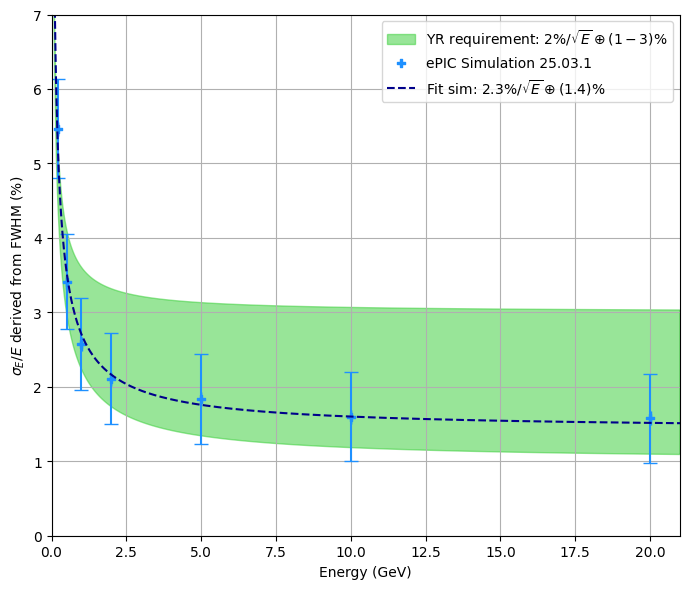

In [ ]:
# Plotting the acceptance zone
plt.figure(figsize=(7, 6))
plt.fill_between(E, fit_curve_up, fit_curve_low, color='limegreen', alpha=0.5, label='YR requirement: $2\\%/\\sqrt{E} \\oplus (1-3)\\%$')
# Plotting the energy points
plt.scatter(peak_energy, energy_resolution, marker='P', color='dodgerblue', label='ePIC Simulation 25.03.1')
plt.errorbar(peak_energy, energy_resolution, xerr=peak_energy_err, yerr=energy_resolution_err, fmt='none', ecolor='dodgerblue', capsize=5)
plt.plot(E, fit_Sigma, color='darkblue', linestyle='--', label=f'Fit sim: ${a_fit:.1f}\\%/\\sqrt{{E}} \\oplus ({b_fit:.1f})\\%$')
# Plotting the energy with 2mm of Cu
# plt.scatter(peak_energy_2mmCu, energy_resolution_2mmCu, marker='*', color='orange', label='ePIC Simulation 25.03.1 w/ 2mm Cu')
# plt.errorbar(peak_energy_2mmCu, energy_resolution_2mmCu, xerr=peak_energy_err, yerr=energy_resolution_2mmCu_err, fmt='none', ecolor='orange', capsize=5)
# plt.plot(E, fit_Sigma_2mmCu, color='darkorange', linestyle='--', label=f'Fit sim w/ 2mm Cu: ${a_fit_2mmCu:.1f}\\%/\\sqrt{{E}} \\oplus ({b_fit_2mmCu:.1f})\\%$')
# # Plotting the energy with 5mm of Cu
# plt.scatter(peak_energy_5mmCu, energy_resolution_5mmCu, marker='^', color='red', label='ePIC Simulation 25.03.1 w/ 5mm Cu')
# plt.errorbar(peak_energy_5mmCu, energy_resolution_5mmCu, xerr=peak_energy_err, yerr=energy_resolution_5mmCu_err, fmt='none', ecolor='red', capsize=5)
# plt.plot(E, fit_Sigma_5mmCu, color='darkred', linestyle='--', label=f'Fit sim w/ 5mm Cu: ${a_fit_5mmCu:.1f}\\%/\\sqrt{{E}} \\oplus ({b_fit_5mmCu:.1e})\\%$')

plt.xlabel('Energy (GeV)')
plt.ylabel(r'$\sigma_E / E$ derived from FWHM (%)')
plt.ylim(0, 7)
plt.xlim(0, 21)
#plt.gca().xaxis.set_major_locator(MultipleLocator(0.1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
energy_resolution_2mmCu

array([5.10230869, 2.24688307, 0.98086246, 0.75357817, 0.44006311,
       0.51430946, 0.55021282])

# **Energy Reconstruction approach**

In [ ]:
# Create energy array
E = np.linspace(0.01, 21, 1000)  # Avoid division by zero
E_fit = np.linspace(0.5, 20, 1000)

# Define the upper and lower bounds of the theoretical curve
fit_curve_up = np.sqrt((0.02 / np.sqrt(E))**2 + 0.03**2) * 100  # upper bound
fit_curve_low = np.sqrt((0.02 / np.sqrt(E))**2 + 0.01**2) * 100  # lower bound
fit_curve_sim = np.sqrt((0.018 / np.sqrt(E))**2 + 0.015**2) * 100  # sim before

#Offset
offset = np.array([0.0, 0.5, 0.5, 0.7, 0.7, 0.9, 1, 1])

# Data points original
peak_energy = np.array([0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0])
energy_resolution = np.array([17.787, 4.62515, 2.47225, 1.60085, 1.14488, 0.781164, 0.655235, 0.651503])+offset
energy_resolution_err = np.array([0.465477, 0.0799861, 0.0239629, 0.0174722, 0.00883618, 0.00656226, 0.00991188, 0.0084165])
# energy_resolution = np.array([4.62469, 2.59837, 1.85211, 1.39432, 1.28078, 1.9539, 1.68455])
# energy_resolution_err = np.array([0.0827505, 0.032819, 0.0239072, 0.0179507, 0.0478882, 0.304632, 0.636617])

# Data points 2mm of Cu
energy_resolution_2mmCu = np.array([17.787, 5.02731, 2.47845, 1.71646, 1.12695, 0.781349, 0.644154, 0.631915])+offset
energy_resolution_2mmCu_err = np.array([0.465477, 0.0958959, 0.0262701, 0.01544880, 0.00912396, 0.00740323, 0.0102337, 0.00810042])
# energy_resolution_2mmCu = np.array([5.02731, 2.58221, 1.84008, 1.39277, 1.20386, 1.68817, 3.56479])
# energy_resolution_2mmCu_err = np.array([0.0958959, 0.0345688, 0.0238425, 0.0177217, 0.0403272, 0.258646, 0.254293])


# Data points 5mm of Cu
energy_resolution_5mmCu = np.array([16.0337, 5.34925, 2.58952, 1.77872, 1.27356, 0.779727, 0.635461, 0.618929])+offset
energy_resolution_5mmCu_err = np.array([0.488945, 0.0908052, 0.0272687, 0.0246591, 0.0107431, 0.00794383, 0.0134366, 0.0079403])
# energy_resolution_5mmCu = np.array([5.34925, 2.58952, 2.72325, 1.35587, 1.13925, 1.50509, 4.56848])
# energy_resolution_5mmCu_err = np.array([0.0908052, 0.0272687, 0.00251234, 0.0163949, 0.031487, 0.224476, 0.0992923])

In [ ]:
# Define the fitting function
def resolution_model(E, a, b):
    return np.sqrt((a / np.sqrt(E))**2 + b**2)

p0 = [1.0, 1.0]  # guess values
bounds = (0, [np.inf, np.inf])  # restrict to positive values

# Perform the curve fitting
params, covariance = curve_fit(resolution_model, peak_energy[2:], energy_resolution[2:], p0=p0, bounds=bounds)
a_fit, b_fit = params

params_2mmCu, covariance_2mmCu = curve_fit(resolution_model, peak_energy[2:], energy_resolution_2mmCu[2:], bounds=bounds)
a_fit_2mmCu, b_fit_2mmCu = params_2mmCu

params_5mmCu, covariance_5mmCu = curve_fit(resolution_model, peak_energy[2:], energy_resolution_5mmCu[2:], bounds=bounds)
a_fit_5mmCu, b_fit_5mmCu = params_5mmCu

# Generate fitted curve
fit_Sigma = resolution_model(E_fit, a_fit, b_fit)
fit_Sigma_2mmCu = resolution_model(E_fit, a_fit_2mmCu, b_fit_2mmCu)
fit_Sigma_5mmCu = resolution_model(E_fit, a_fit_5mmCu, b_fit_5mmCu)

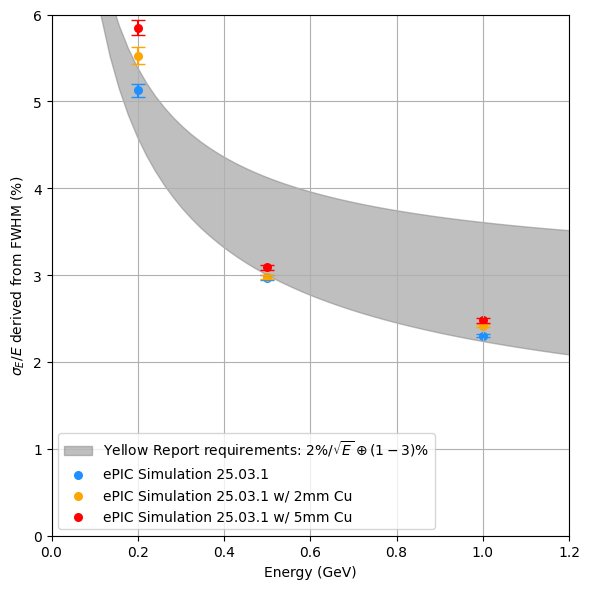

In [ ]:
# Plotting the acceptance zone
plt.figure(figsize=(6, 6))
plt.fill_between(E, fit_curve_up, fit_curve_low, color='gray', alpha=0.5, label='Yellow Report requirements: $2\\%/\\sqrt{E} \\oplus (1-3)\\%$')
#Plotting model before
#plt.plot(E, fit_curve_sim, color='darkgreen', linestyle='--', label='Model before: $1.8\\%/\\sqrt{E} \\oplus (1.5)\\%$')
# Plotting the energy points
plt.scatter(peak_energy, energy_resolution, marker='o', s=30, color='dodgerblue', label='ePIC Simulation 25.03.1')
plt.errorbar(peak_energy, energy_resolution, xerr=None, yerr=energy_resolution_err, fmt='none', ecolor='dodgerblue', capsize=5)
#plt.plot(E_fit, fit_Sigma, color='darkblue', linestyle='--', label=f'Functional fit - sim w/o Cu: $({a_fit:.2f})\\%/\\sqrt{{E}} \\oplus ({b_fit:.2f})\\%$')
# Plotting the energy with 2mm of Cu
plt.scatter(peak_energy, energy_resolution_2mmCu, marker='o', s=30, color='orange', label='ePIC Simulation 25.03.1 w/ 2mm Cu')
plt.errorbar(peak_energy, energy_resolution_2mmCu, xerr=None, yerr=energy_resolution_2mmCu_err, fmt='none', ecolor='orange', capsize=5)
#plt.plot(E_fit, fit_Sigma_2mmCu, color='darkorange', linestyle='--', label=f'Functional fit - sim w/ 2mm Cu: $({a_fit_2mmCu:.2f})\\%/\\sqrt{{E}} \\oplus ({b_fit_2mmCu:.2f})\\%$')
# # Plotting the energy with 5mm of Cu
plt.scatter(peak_energy, energy_resolution_5mmCu, marker='o', s=30, color='red', label='ePIC Simulation 25.03.1 w/ 5mm Cu')
plt.errorbar(peak_energy, energy_resolution_5mmCu, xerr=None, yerr=energy_resolution_5mmCu_err, fmt='none', ecolor='red', capsize=5)
#plt.plot(E_fit, fit_Sigma_5mmCu, color='darkred', linestyle='--', label=f'Functional fit - sim w/ 5mm Cu:: $({a_fit_5mmCu:.2f})\\%/\\sqrt{{E}} \\oplus ({b_fit_5mmCu:.2f})\\%$')

plt.xlabel('Energy (GeV)')
plt.ylabel(r'$\sigma_E / E$ derived from FWHM (%)')
plt.ylim(0, 6)
plt.xlim(0, 1.2)
#plt.gca().xaxis.set_major_locator(MultipleLocator(0.1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
fit_curve_sim_value = np.sqrt((0.018 / np.sqrt(0.5))**2 + 0.015**2) * 100
print(fit_curve_sim_value)

2.9546573405388314


# **Photons energy reconstruction**

In [ ]:
# Create energy array
E = np.linspace(0.01, 2, 1000)  # Avoid division by zero

# Define the upper and lower bounds of the theoretical curve
fit_curve_up = np.sqrt((0.02 / np.sqrt(E))**2 + 0.03**2) * 100  # upper bound
fit_curve_low = np.sqrt((0.02 / np.sqrt(E))**2 + 0.01**2) * 100  # lower bound
fit_curve_sim = np.sqrt((0.018 / np.sqrt(E))**2 + 0.015**2) * 100  # sim before

#Offset
offset = np.array([0.5, 0.5, 0.7])

# # Data points original
peak_energy = np.array([0.2, 0.5, 1.0])
energy_resolution = np.array([3.87282, 2.38217, 1.54338])+offset
energy_resolution_err = np.array([0.0468936, 0.023922, 0.0146149])

# Data points 2mm of Cu
energy_resolution_2mmCu = np.array([4.1123, 2.38172, 1.57793])+offset
energy_resolution_2mmCu_err = np.array([0.0849482, 0.0217823, 0.0146805])


# Data points 5mm of Cu
energy_resolution_5mmCu = np.array([4.14613, 2.42558, 1.69755])+offset
energy_resolution_5mmCu_err = np.array([0.0503213, 0.0300867, 0.0187117])

In [ ]:
np.sqrt((0.018 / np.sqrt(0.1349766/2))**2 + 0.015**2) * 100

np.float64(7.089310364371371)

In [ ]:
# Define the fitting function
def resolution_model(E, a, b):
    return np.sqrt((a / np.sqrt(E))**2 + b**2)

p0 = [1.0, 1.0]  # guess values
bounds = (0, [np.inf, np.inf])  # restrict to positive values

# Perform the curve fitting
params, covariance = curve_fit(resolution_model, peak_energy, energy_resolution, p0=p0, bounds=bounds)
a_fit, b_fit = params

params_2mmCu, covariance_2mmCu = curve_fit(resolution_model, peak_energy, energy_resolution_2mmCu, bounds=bounds)
a_fit_2mmCu, b_fit_2mmCu = params_2mmCu

params_5mmCu, covariance_5mmCu = curve_fit(resolution_model, peak_energy, energy_resolution_5mmCu, bounds=bounds)
a_fit_5mmCu, b_fit_5mmCu = params_5mmCu

# Generate fitted curve
fit_Sigma = resolution_model(E, a_fit, b_fit)
fit_Sigma_2mmCu = resolution_model(E, a_fit_2mmCu, b_fit_2mmCu)
fit_Sigma_5mmCu = resolution_model(E, a_fit_5mmCu, b_fit_5mmCu)

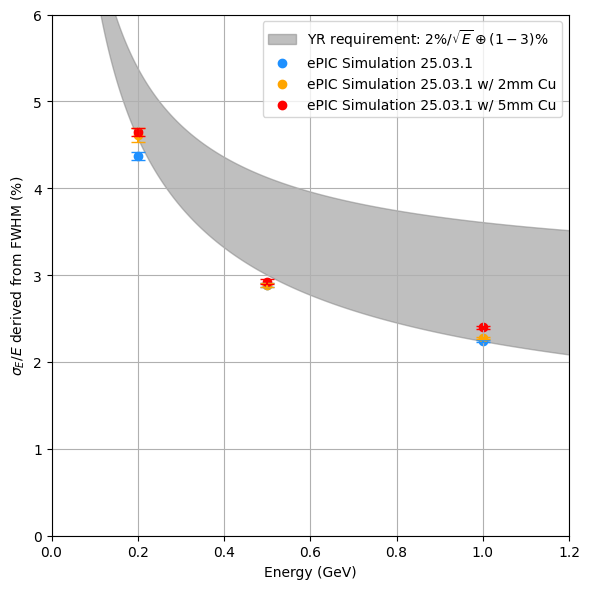

In [ ]:
# Plotting the acceptance zone
plt.figure(figsize=(6, 6))
plt.fill_between(E, fit_curve_up, fit_curve_low, color='gray', alpha=0.5, label='YR requirement: $2\\%/\\sqrt{E} \\oplus (1-3)\\%$')
#Plotting model before
# plt.plot(E, fit_curve_sim, color='darkgreen', linestyle='--', label='Model before: $1.8\\%/\\sqrt{E} \\oplus (1.5)\\%$')
# Plotting the energy points
plt.scatter(peak_energy, energy_resolution, marker='o', color='dodgerblue', label='ePIC Simulation 25.03.1')
plt.errorbar(peak_energy, energy_resolution, xerr=None, yerr=energy_resolution_err, fmt='none', ecolor='dodgerblue', capsize=5)
#plt.plot(E, fit_Sigma, color='darkblue', linestyle='--', label=f'Fit sim: $({a_fit:.1f})\\%/\\sqrt{{E}} \\oplus ({b_fit:.1f})\\%$')
# Plotting the energy with 2mm of Cu
plt.scatter(peak_energy_2mmCu, energy_resolution_2mmCu, marker='o', color='orange', label='ePIC Simulation 25.03.1 w/ 2mm Cu')
plt.errorbar(peak_energy_2mmCu, energy_resolution_2mmCu, xerr=None, yerr=energy_resolution_2mmCu_err, fmt='none', ecolor='orange', capsize=5)
#plt.plot(E, fit_Sigma_2mmCu, color='darkorange', linestyle='--', label=f'Fit sim w/ 2mm Cu: $({a_fit_2mmCu:.1f})\\%/\\sqrt{{E}} \\oplus ({b_fit_2mmCu:.1f})\\%$')
# Plotting the energy with 5mm of Cu
plt.scatter(peak_energy_5mmCu, energy_resolution_5mmCu, marker='o', color='red', label='ePIC Simulation 25.03.1 w/ 5mm Cu')
plt.errorbar(peak_energy_5mmCu, energy_resolution_5mmCu, xerr=None, yerr=energy_resolution_5mmCu_err, fmt='none', ecolor='red', capsize=5)
#plt.plot(E, fit_Sigma_5mmCu, color='darkred', linestyle='--', label=f'Fit sim w/ 5mm Cu: $({a_fit_5mmCu:.1f})\\%/\\sqrt{{E}} \\oplus ({b_fit_5mmCu:.1f})\\%$')

plt.xlabel('Energy (GeV)')
plt.ylabel(r'$\sigma_E / E$ derived from FWHM (%)')
plt.ylim(0, 6)
plt.xlim(0, 1.2)
#plt.gca().xaxis.set_major_locator(MultipleLocator(0.1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()